In [1]:
%reload_ext autoreload
%autoreload 2
from importlib import reload

import os
import sys
import pickle
import logging
import warnings
import numpy as np
import astropy as ap
import scipy as sp
import scipy.stats
import matplotlib as mpl
import matplotlib.pyplot as plt

import h5py
import tqdm.notebook as tqdm

import kalepy as kale
import kalepy.utils
import kalepy.plot

import holodeck as holo
import holodeck.sams
import holodeck.gravwaves
from holodeck import cosmo, utils, plot, discrete, sams, host_relations, _PATH_DATA
from holodeck.constants import MSOL, PC, YR, MPC, GYR, SPLC
from pathlib import Path

import compare_discrete

# Silence annoying numpy errors
np.seterr(divide='ignore', invalid='ignore', over='ignore')
warnings.filterwarnings("ignore", category=UserWarning)

# Plotting settings
mpl.rc('font', **{'family': 'serif', 'sans-serif': ['Times'], 'size': 15})
mpl.rc('lines', solid_capstyle='round')
mpl.rc('mathtext', fontset='cm')
plt.rcParams.update({'grid.alpha': 0.5})
mpl.style.use('default')   # avoid dark backgrounds from dark theme vscode

log = holo.log
log.setLevel(logging.INFO)

# ---- Define filepath containing simulation galaxy merger data files ----#
# ---- (if using files not in _PATH_DATA) ---- #
_HOME_PATH = Path('~/').expanduser()
p = os.path.join(_HOME_PATH, 'cosmo_sim_merger_data')
if os.path.exists(p):
    _SIM_MERGER_PATH = p
else:
    p = os.path.join(_HOME_PATH, 'nanograv/cosmo_sim_merger_data')
    if os.path.exists(p):
        _SIM_MERGER_PATH = p
    else:
        _SIM_MERGER_PATH = _PATH_DATA
# ------------------------------------------------------------------------ #

In [3]:
ill_pkl_fname='dpops_nfreqs40_nreals500_nloud10_tau1.0_compare_Illustris_cuts_with_fsa.pkl'
with open(ill_pkl_fname, "rb") as f:
    print("unpickling dpop data")
    dp_data = pickle.load(f)
    for l in dp_data:
        if len(l) > 0:
            for i in range(len(l)):
                #print(l[i])
                print(l[i].lbl)
        
    all_dpops, tng_dpops, all_fsa_dpops, tng_fsa_dpops = dp_data

gpf_pkl_fname='sam_nfreqs40_nreals500_nloud10_tau1.0_gpf.pkl'
with open(gpf_pkl_fname, "rb") as f:
    print("unpickling GPF SAM data")
    gpf_data = pickle.load(f)
    sam_gpf, hard_gpf, gwb_new_sam_gpf, gwb_sam_gpf, freqs_gpf, freqs_edges_gpf = gpf_data

gmr_pkl_fname='sam_nfreqs40_nreals500_nloud10_tau1.0_gmr.pkl'
with open(gmr_pkl_fname, "rb") as f:
    print("unpickling GMR SAM data")
    gmr_data = pickle.load(f)
    sam_gmr, hard_gmr, gwb_new_sam_gmr, gwb_sam_gmr, freqs_gmr, freqs_edges_gmr = gmr_data

unpickling dpop data
fsa-mm-Illustris-1-N001-bh1
fsa-mm-Illustris-1-N010-bh0
fsa-mm-Illustris-1-N010-bh1
fsa-mm-Illustris-1-bh0
fsa-mm-Illustris-1
unpickling GPF SAM data
unpickling GMR SAM data


In [4]:
def plot_bin_pop(pop):
    mt, mr = utils.mtmr_from_m1m2(pop.mass)
    redz = cosmo.a_to_z(pop.scafa)
    data = [mt/MSOL, mr, pop.sepa/PC, 1+redz]
    data = [np.log10(dd) for dd in data]
    reflect = [None, [None, 0], None, [0, None]]
    labels = [r'M/M_\odot', 'q', r'a/\mathrm{{pc}}', '1+z']
    labels = [r'${{\log_{{10}}}} \left({}\right)$'.format(ll) for ll in labels]

    if pop.eccen is not None:
        data.append(pop.eccen)
        reflect.append([0.0, 1.0])
        labels.append('e')

    kde = kale.KDE(data, reflect=reflect)
    corner = kale.Corner(kde, labels=labels, figsize=[8, 8])
    corner.plot_data(kde)
    return corner

def compare_bin_pops(dpops, labels=None, var='mass', colors=None, lws=None, 
                     density=True, hist=False, confidence=False):
    
    assert isinstance(dpops, list), '`dpops` must be a list of discrete populations'
    assert var in ['mass','mrat','sepa','redz'], "`var` must be 'mass','mrat','sepa', or 'redz'."
    if (labels is not None):
        if (len(labels) != len(dpops)) and (not isinstance(labels,str)):
            print("Warning: `labels` must be a str or a list of length len(dpops). Setting to None.")
            labels = None
    if (colors is not None):
        if (len(colors) != len(dpops)):
            print("Warning: `colors` must be a list of length len(dpops). Setting to None.")
            colors = None
    if (lws is not None):
        if (len(lws) != len(dpops)):
            print("Warning: `lws` must be a list of length len(dpops). Setting to None.")
            lws = None
   
    fig, ax = plt.subplots(figsize=[10, 5])
    ax.set(ylabel='Probability Density')
    ax.grid(alpha=0.01)
    
    if (var == 'mass') or (var == 'mrat'):
        for i,dp in enumerate(dpops):
            mt, mr = utils.mtmr_from_m1m2(dp.pop.mass)
            data = np.log10(mt/MSOL) if var=='mass' else mr
            #print(data.min(),data.max())
            xlab = r'$\log_{10}(M_{tot})$' if var=='mass' else r'$q$'
            ax.set(xlabel=xlab)
            if colors is None:
                kale.dist1d(data, density=density, hist=hist, confidence=confidence, 
                            label=dp.lbl, color=dp.color, lw=dp.lw)
            else: 
                kale.dist1d(data, density=density, hist=hist, confidence=confidence, 
                            label=labels[i], color=colors[i], lw=lws[i])

    elif var == 'sepa':
        for i,dp in enumerate(dpops):
            data = np.log10(dp.pop.sepa/PC)
            #print(data.min(),data.max())
            ax.set(xlabel=r'$\log_{10}(a) [pc]$')
            if colors is None:
                kale.dist1d(data, density=density, hist=hist, confidence=confidence, 
                            label=dp.lbl, color=dp.color, lw=dp.lw)
            else: 
                kale.dist1d(data, density=density, hist=hist, confidence=confidence, 
                            label=labels[i], color=colors[i], lw=lws[i])

    else:
        for i,dp in enumerate(dpops):
            redz = cosmo.a_to_z(dp.pop.scafa)
            data = 1+redz
            #print(data.min(),data.max())
            ax.set(xlabel=r'$\log_{10}(1+z)$')
            if colors is None:
                kale.dist1d(data, density=density, hist=hist, confidence=confidence, 
                            label=dp.lbl, color=dp.color, lw=dp.lw)
            else: 
                kale.dist1d(data, density=density, hist=hist, confidence=confidence, 
 
                            label=labels[i], color=colors[i], lw=lws[i])


In [5]:
def plot_mbh_scaling_relations(dpop, fname=None, color='r', compare_dpops=None, ncols=1, nrows=1,
                               xlim=None, ylim=None):
    units = r"$[\log_{10}(M/M_\odot)]$"

    if compare_dpops == None:
        fig, axes = plt.subplots(figsize=[10, 8])
        dpops = [dpop]
    else:
        #fig, axes = plt.subplots(figsize=[12,5], ncols=ncols, nrows=nrows)
        fig, axes = plt.subplots(figsize=[10,8], ncols=ncols, nrows=nrows)
        dpops = [dpop] + compare_dpops
        if len(dpops) > ncols*nrows:
            raise ValueError(f"len(dpops)>ncols*nrows. ({len(dpops)} > {ncols}*{nrows}).")

    print([d.lbl for d in dpops])
    i = 0
    for idx, ax in np.ndenumerate(axes):
        print(f"{i=}, {dpops[i].lbl=}")
        if i > len(dpops): break

        print(f"idx: {idx}, i: {i}")
        ax.set(xlabel=f'Stellar Mass {units}', ylabel=f'BH Mass {units}')
        if xlim is not None: ax.set(xlim=xlim)
        if ylim is not None: ax.set(ylim=ylim)

        #   ====    Plot McConnell+Ma-2013 Data    ====
        handles = []
        names = []
        if fname is not None:
            hh = _draw_MM2013_data(ax, fname)
            handles.append(hh)
            names.append('McConnell+Ma')

        #   ====    Plot MBH Merger Data    ====
        hh, nn = _draw_pop_masses(ax, dpops[i].pop, color, nplot=1e6)
        handles = handles + hh
        names = names + nn
        ax.set_title(dpops[i].lbl)
        ax.legend(handles, names)
        
        i += 1

    return fig

def _draw_MM2013_data(ax):
    data = holo.observations.load_mcconnell_ma_2013()
    data = {kk: data[kk] if kk == 'name' else np.log10(data[kk]) for kk in data.keys()}
    key = 'mbulge'
    mass = data['mass']
    yy = mass[:, 1]
    yerr = np.array([yy - mass[:, 0], mass[:, 2] - yy])
    vals = data[key]
    if np.ndim(vals) == 1:
        xx = vals
        xerr = None
    elif vals.shape[1] == 2:
        xx = vals[:, 0]
        xerr = vals[:, 1]
    elif vals.shape[1] == 3:
        xx = vals[:, 1]
        xerr = np.array([xx-vals[:, 0], vals[:, 2]-xx])
    else:
        raise ValueError()

    idx = (xx > 0.0) & (yy > 0.0)
    if xerr is not None:
        xerr = xerr[:, idx]
    ax.errorbar(xx[idx], yy[idx], xerr=xerr, yerr=yerr[:, idx], fmt='none', zorder=10)
    handle = ax.scatter(xx[idx], yy[idx], zorder=10)
    ax.set(ylabel='MBH Mass', xlabel=key)

    return handle

def _draw_pop_masses(ax, pop, color='r', nplot=3e3):
    print(pop.mbulge.shape, pop.mass.shape)
    #xx = pop.mbulge.flatten() / MSOL
    xx = pop.mbulge[:,:2].flatten() / MSOL
    yy_list = [pop.mass]
    names = ['new']
    if hasattr(pop, '_mass'):
        yy_list.append(pop._mass)
        names.append('old')

    colors = [color, '0.5']
    handles = []
    if xx.size > nplot:
        cut = np.random.choice(xx.size, int(nplot), replace=False)
        print("Plotting {:.1e}/{:.1e} data-points".format(nplot, xx.size))
    else:
        cut = slice(None)

    for ii, yy in enumerate(yy_list):
        yy = yy.flatten() / MSOL
        data = np.log10([xx[cut], yy[cut]])
        kale.plot.dist2d(
            data, ax=ax, color=colors[ii], hist=False, contour=True,
            median=True, mask_dense=True,
        )
        hh, = plt.plot([], [], color=colors[ii])
        handles.append(hh)

    return handles, names



In [6]:
#tmp = compare_discrete.create_dpops(allow_mbh0=True, mod_mmbulge=True, skip_evo=True, fpath=_SIM_MERGER_PATH)
#all_dpops, tng_dpops, all_fsa_dpops, tng_fsa_dpops = tmp

['fsa-mm-Illustris-1-N001-bh1', 'fsa-mm-Illustris-1-N010-bh0', 'fsa-mm-Illustris-1-N010-bh1', 'fsa-mm-Illustris-1-bh0', 'fsa-mm-Illustris-1']
i=0, dpops[i].lbl='fsa-mm-Illustris-1-N001-bh1'
idx: (0, 0), i: 0
(4725, 2) (4725, 2)
i=1, dpops[i].lbl='fsa-mm-Illustris-1-N010-bh0'
idx: (0, 1), i: 1
(183454, 2) (183454, 2)


ERROR:root:Given extrema ([       -inf 10.32548646]) contain non-finite values!  Overriding!
ERROR:root:Given extrema ([nan nan]) contain non-finite values!  Overriding!
ERROR:root:Failed to construct cholesky on [[nan nan]
 [nan nan]], [[0.02696298        nan]
 [       nan        nan]]


ValueError: array must not contain infs or NaNs

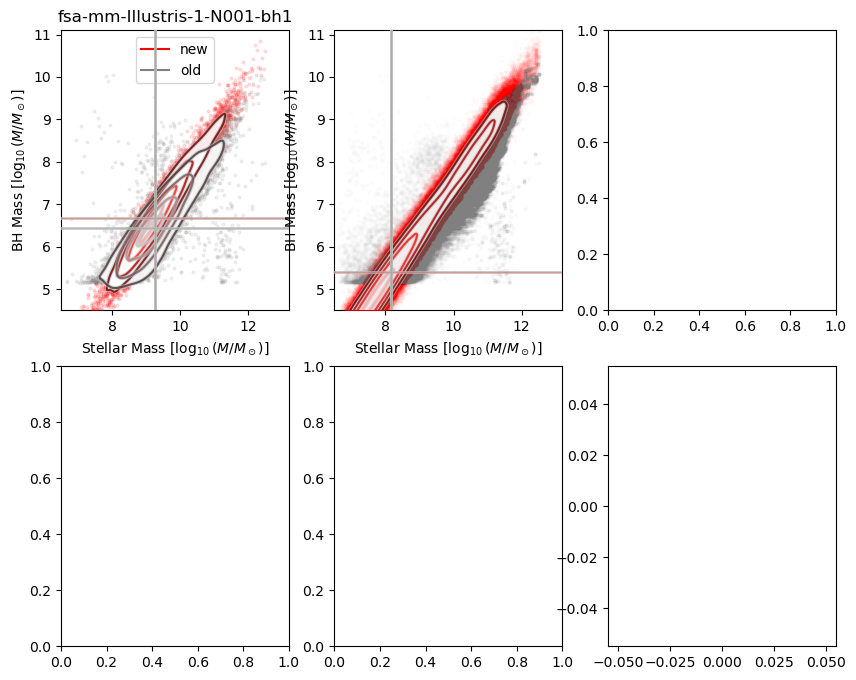

In [8]:
plot_mbh_scaling_relations(all_fsa_dpops[0], compare_dpops=[d for d in all_fsa_dpops[1:]], 
                           ncols=3, nrows=2, xlim=(6.5,13.2), ylim=(4.5,11.1))
plt.savefig('mmbulge_relations.png', dpi=300)
plt.show()